In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv(r'C:\Users\vaish\OneDrive\Desktop\Sales_Forecating\data\SuperStoreOrders.csv')

In [4]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [5]:
print(df.shape)

print(df.columns)

print(df.info())

print(df.isnull().sum())

(51290, 21)
Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  str    
 1   order_date      51290 non-null  str    
 2   ship_date       51290 non-null  str    
 3   ship_mode       51290 non-null  str    
 4   customer_name   51290 non-null  str    
 5   segment         51290 non-null  str    
 6   state           51290 non-null  str    
 7   country         51290 non-null  str    
 8   market          51290 non-null  str    
 9   region          51290 non-null  str    
 10  product_id      51290 non-null  s

In [6]:
print(df.columns)

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='str')


In [9]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

KeyError: 'Order Date'

In [10]:
df['order_date'] = pd.to_datetime(df['order_date'])

ValueError: time data "13-01-2011" doesn't match format "%m/%d/%Y". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [11]:
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)

ValueError: time data "13-01-2011" doesn't match format "%d/%m/%Y". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [12]:
df['order_date'] = pd.to_datetime(df['order_date'],
                                  format='%d-%m-%Y')

ValueError: time data "1/1/2011" doesn't match format "%d-%m-%Y". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [13]:
df['order_date'] = pd.to_datetime(
    df['order_date'],
    format='mixed',
    dayfirst=True
)

In [14]:
print(df['order_date'].isnull().sum())

0


In [15]:
print(df[df['order_date'].isnull()])

Empty DataFrame
Columns: [order_id, order_date, ship_date, ship_mode, customer_name, segment, state, country, market, region, product_id, category, sub_category, product_name, sales, quantity, discount, profit, shipping_cost, order_priority, year]
Index: []

[0 rows x 21 columns]


In [16]:
# Set date column as index
df.set_index('order_date', inplace=True)

# Check column names
print(df.columns)

Index(['order_id', 'ship_date', 'ship_mode', 'customer_name', 'segment',
       'state', 'country', 'market', 'region', 'product_id', 'category',
       'sub_category', 'product_name', 'sales', 'quantity', 'discount',
       'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='str')


In [17]:
df.head()

,order_id,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
order_date,,,,,,,,,,,,,,,,,,,,
2011-01-01,AG-2011-2040,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
2011-01-01,IN-2011-47883,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2011-01-01,HU-2011-1220,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,OFF-TEN-10001585,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
2011-01-01,IT-2011-3647632,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,OFF-PA-10001492,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
2011-01-01,IN-2011-47883,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,FUR-FU-10003447,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [19]:
sales = df['sales'].resample('D').sum()

In [20]:
sales.head()

order_date
2011-01-01                                      408120664511455
2011-01-02                                                  314
2011-01-03    2769126673382118541931591951236969135365262814...
2011-01-04              1,6482231861401491667438383927162717156
2011-01-05                                   3,0292079027349124
Freq: D, Name: sales, dtype: str

In [23]:
print(df.columns.tolist())

['order_id', 'ship_date', 'ship_mode', 'customer_name', 'segment', 'state', 'country', 'market', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'order_priority', 'year']


In [24]:
print(df['sales'].dtype)

str


In [25]:
# Remove commas if present
df['sales'] = df['sales'].str.replace(',', '', regex=False)

# Convert to numeric
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')

# Check the datatype again
print(df['sales'].dtype)

int64


In [26]:
print(df['sales'].isnull().sum())

0


In [27]:
df = df.dropna(subset=['sales'])

In [29]:
# Convert ship_date to datetime
df['ship_date'] = pd.to_datetime(
    df['ship_date'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

# Set ship_date as index
df.set_index('ship_date', inplace=True)

# Resample daily sales
sales = df['sales'].resample('D').sum()

print(sales.head())

ship_date
2011-01-03     312
2011-01-04       0
2011-01-05     111
2011-01-06     722
2011-01-07    2879
Freq: D, Name: sales, dtype: int64


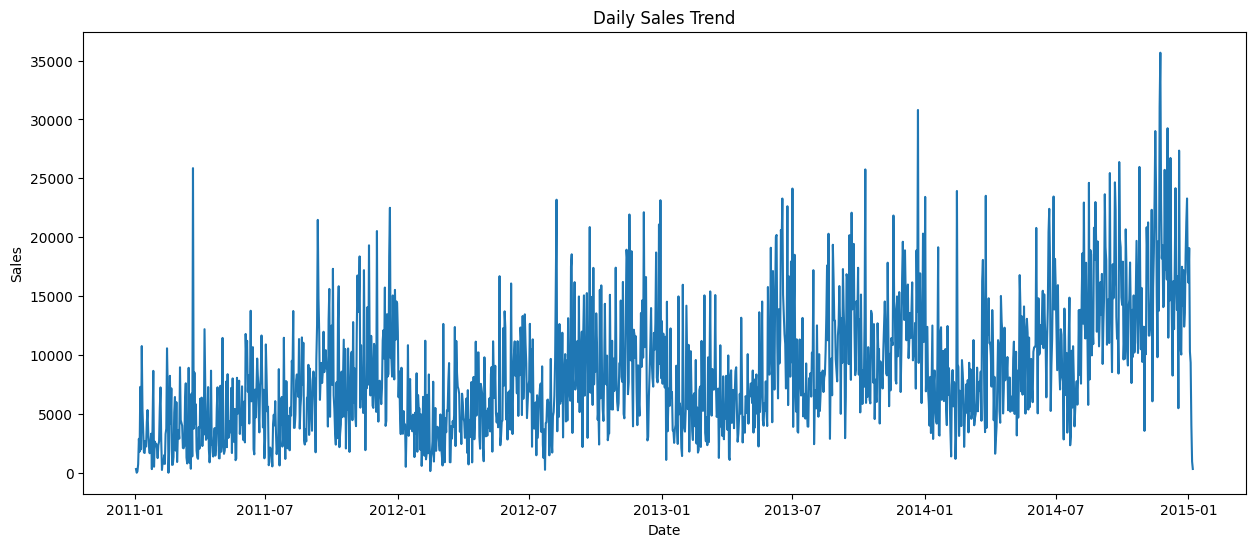

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))
plt.plot(sales)
plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

In [32]:
import os
print(os.getcwd())

C:\Users\vaish\OneDrive\Desktop\Sales_Forecating


In [33]:
plt.savefig('outputs/sales_trend.png')

<Figure size 640x480 with 0 Axes>

In [34]:
monthly_sales = sales.resample('ME').sum()

print(monthly_sales.head())

ship_date
2011-01-31     86920
2011-02-28     96303
2011-03-31    134787
2011-04-30    121202
2011-05-31    139580
Freq: ME, Name: sales, dtype: int64


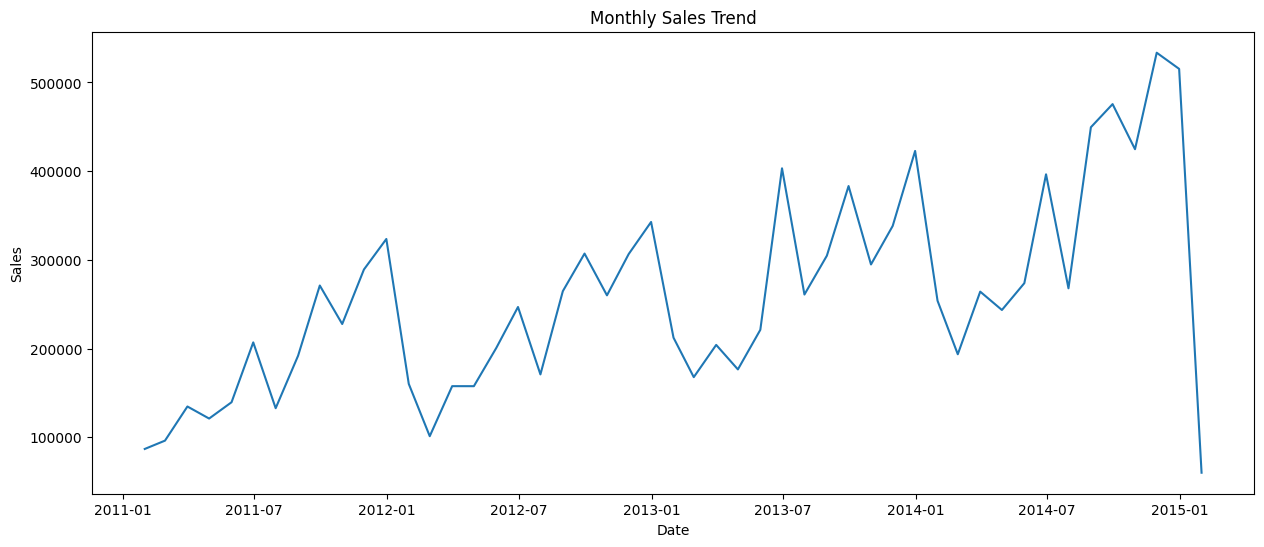

In [35]:
plt.figure(figsize=(15,6))
plt.plot(monthly_sales)
plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

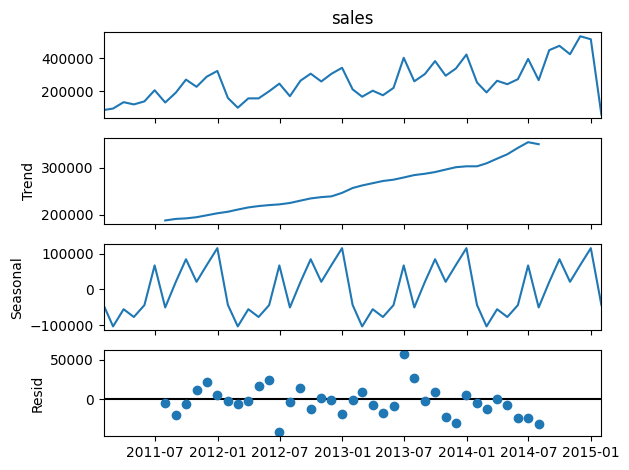

In [36]:
decomposition = seasonal_decompose(monthly_sales,
                                   model='additive')

decomposition.plot()
plt.show()

In [37]:
plt.savefig('outputs/decomposition_plot.png')

<Figure size 640x480 with 0 Axes>

In [38]:
train = monthly_sales[:-12]

test = monthly_sales[-12:]

In [39]:
print(len(train))
print(len(test))

37
12


In [40]:
model = ARIMA(train, order=(5,1,0))

model_fit = model.fit()



In [41]:
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                   37
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -445.357
Date:                Sun, 28 Jun 2026   AIC                            902.714
Time:                        12:03:03   BIC                            912.215
Sample:                    01-31-2011   HQIC                           906.030
                         - 01-31-2014                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1465      0.165     -0.886      0.375      -0.470       0.177
ar.L2         -0.3019      0.175     -1.728      0.084      -0.644       0.041
ar.L3          0.2514      0.216      1.162      0.2

In [42]:
forecast = model_fit.forecast(steps=12)

print(forecast)

2014-02-28    282879.416214
2014-03-31    351892.451753
2014-04-30    248341.633175
2014-05-31    299206.623719
2014-06-30    363634.614743
2014-07-31    279654.232627
2014-08-31    311984.668127
2014-09-30    349982.152319
2014-10-31    277682.069707
2014-11-30    304839.941834
2014-12-31    336721.489493
2015-01-31    284049.209459
Freq: ME, Name: predicted_mean, dtype: float64


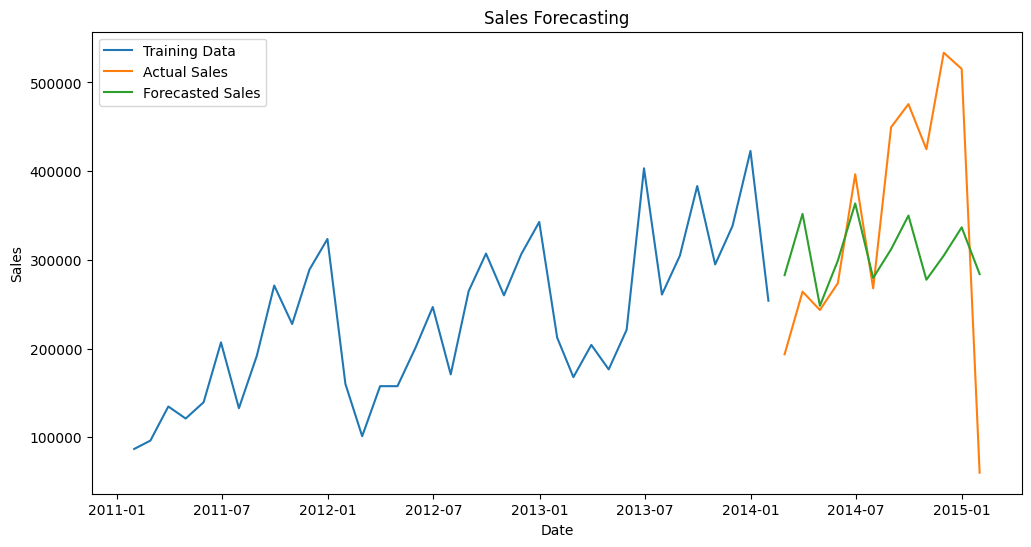

In [43]:
plt.figure(figsize=(12,6))

plt.plot(train.index, train, label='Training Data')
plt.plot(test.index, test, label='Actual Sales')
plt.plot(test.index, forecast, label='Forecasted Sales')

plt.title('Sales Forecasting')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.legend()
plt.show()

In [44]:
plt.savefig('outputs/forecast_plot.png')

<Figure size 640x480 with 0 Axes>

In [45]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print("MAE =", mae)
print("RMSE =", rmse)

MAE = 107760.38589362513
RMSE = 131728.97549830886


In [46]:
future_forecast = model_fit.forecast(steps=6)

print(future_forecast)

2014-02-28    282879.416214
2014-03-31    351892.451753
2014-04-30    248341.633175
2014-05-31    299206.623719
2014-06-30    363634.614743
2014-07-31    279654.232627
Freq: ME, Name: predicted_mean, dtype: float64


In [47]:
future_forecast.to_csv('outputs/future_forecast.csv')

In [48]:
import joblib

joblib.dump(model_fit, 'models/arima_model.pkl')

['models/arima_model.pkl']